In [1]:
#Importing Dependencies
import pandas as pd
import cellrank as cr
import numpy as np
import scanpy as sc
import scvelo as scv
import palantir
from cellrank.kernels import PseudotimeKernel
from cellrank.kernels import CytoTRACEKernel
import scipy.stats as st
from adjustText import adjust_text

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.simplefilter("ignore", category=UserWarning)
warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)


/home/ricsilva/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/ricsilva/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor = 'white', dpi_save = 600, format ="png", transparent = False)
scv.settings.set_figure_params(dpi=80, facecolor = 'white', dpi_save = 600, format ="png", transparent = False,style = 'scvelo')
scv.settings.figdir = '/path/to/folder/'

2025-06-18 12:59:05.564755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-18 12:59:05.578701: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-18 12:59:05.582965: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-18 12:59:06.677161: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


scanpy==1.9.8 anndata==0.10.8 umap==0.5.4 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.1.3 statsmodels==0.14.4 igraph==0.10.8 pynndescent==0.5.10


In [3]:
#Loading File with MAGIC Imputation
adata =  sc.read_h5ad('Seurat_full_magic.h5ad') 

In [4]:
# Running Palantir
start_cell_h = "3D_AATCAGGAGTTTCCGC-1_1"

terminal_states = pd.Series(
    ["Undifferentiated_2D", "Differentiated_2D", "M-like_2D"],
    index=["2D_AAACCGCGTAACTACG-1_1","2D_ACTTAGTCAGGGAGCT-1_1", "2D_TCAGCCTTCGTTTCCA-1_1"],
)
pr_res = palantir.core.run_palantir(adata, start_cell_h ,num_waypoints=500, terminal_states= terminal_states)

Sampling and flocking waypoints...
Time for determining waypoints: 0.037096500396728516 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.49981080293655394 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [5]:
# Obtaining model for gene trends
masks = palantir.presults.select_branch_cells(adata, eps=0)
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)
model = cr.models.GAM(adata)

Undifferentiated_2D
[2025-06-18 13:00:46,546] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (2,616) and rank = 1.0.
[2025-06-18 13:00:46,548] [INFO    ] Using covariance function Matern52(ls=1.0).
Differentiated_2D
[2025-06-18 13:00:59,801] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (15,004) and rank = 1.0.
[2025-06-18 13:00:59,803] [INFO    ] Using covariance function Matern52(ls=1.0).
M-like_2D
[2025-06-18 13:01:31,649] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (6,855) and rank = 1.0.
[2025-06-18 13:01:31,650] [INFO    ] Using covariance function Matern52(ls=1.0).


In [6]:
#Utilizing CellRank Pseudotime Kernel
pk = cr.kernels.PseudotimeKernel(adata, time_key="palantir_pseudotime")
pk.compute_transition_matrix()

  0%|          | 0/36777 [00:00<?, ?cell/s]

PseudotimeKernel[n=36777, dnorm=False, scheme='hard', frac_to_keep=0.3]

saving figure to file /nfs/turbo/umms-cparkos/globus/Ismael/Cellrank_Figures/scvelo_Supp_Fig3A.png


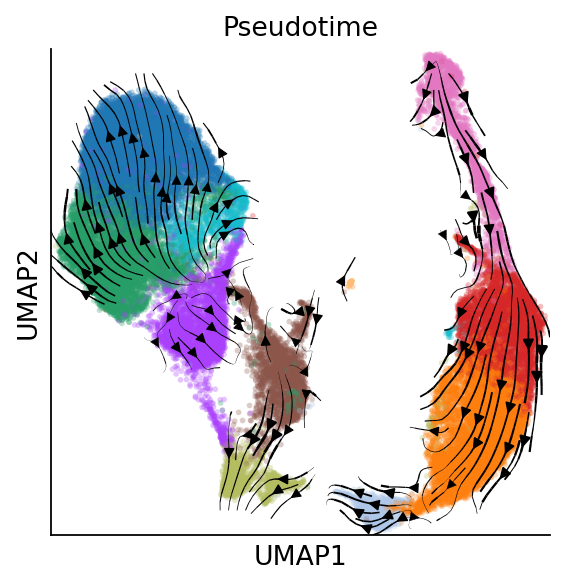

In [9]:
sc.settings.set_figure_params(dpi=80, facecolor = 'white', dpi_save = 600, format ="png", transparent = False)
scv.settings.set_figure_params(dpi=80, facecolor = 'white', dpi_save = 600, format ="png", transparent = True,style = 'scanpy')
matplotlib.rcParams['figure.facecolor'] = "white"
matplotlib.rcParams["axes.grid"] = False
pk.plot_projection(basis="umap", recompute=True, color = "res_35", legend_loc = "none",
                   title = "Pseudotime",
                   save = "Supp_Fig3A.png"
                  )

In [10]:
g2 = cr.estimators.GPCCA(pk)

In [11]:
g2.compute_schur()

GPCCA[kernel=PseudotimeKernel[n=36777], initial_states=None, terminal_states=None]

In [12]:
g2.compute_macrostates(n_states=10, cluster_key="cell_anno")
g2.predict_terminal_states()

GPCCA[kernel=PseudotimeKernel[n=36777], initial_states=None, terminal_states=['BMI+Stem_2D', 'Differentiated_2D', 'Early_G1_3D', 'Hes+Stem_2D', 'Intermediate_2D', 'LGR5+Stem_3D', 'M-like_2D_1', 'M-like_2D_2', 'UC-specific_3D', 'Undifferentiated_2D']]

saving figure to file /nfs/turbo/umms-cparkos/globus/Ismael/Cellrank_Figures/scvelo_Supp_Fig3B_2.png


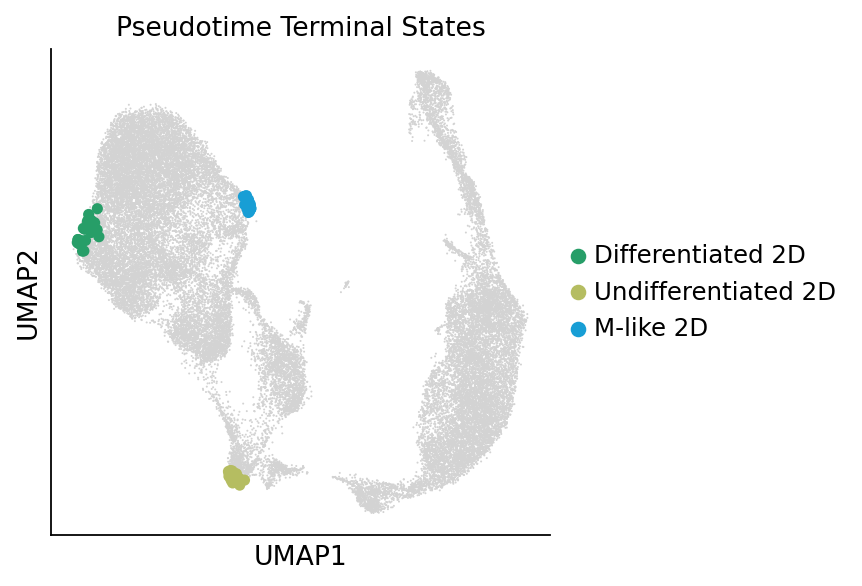

In [13]:
g2.set_terminal_states(states=["Differentiated_2D", "Undifferentiated_2D","M-like_2D_2"])

#Removing the "_2" at the end of "M-like_2D_2"

g2.rename_terminal_states({"Differentiated_2D":"Differentiated_2D",
                          "Undifferentiated_2D":"Undifferentiated_2D",
                          "M-like_2D_2":"M-like_2D"})

g2.plot_macrostates(
    which="terminal", 
    s=100,
    legend_loc= "right", 
    title = "Pseudotime Terminal States",
    save ="Supp_Fig3B_2.png"
)

saving figure to file /nfs/turbo/umms-cparkos/globus/Ismael/Cellrank_Figures/scvelo_Supp_Fig3B_1.png


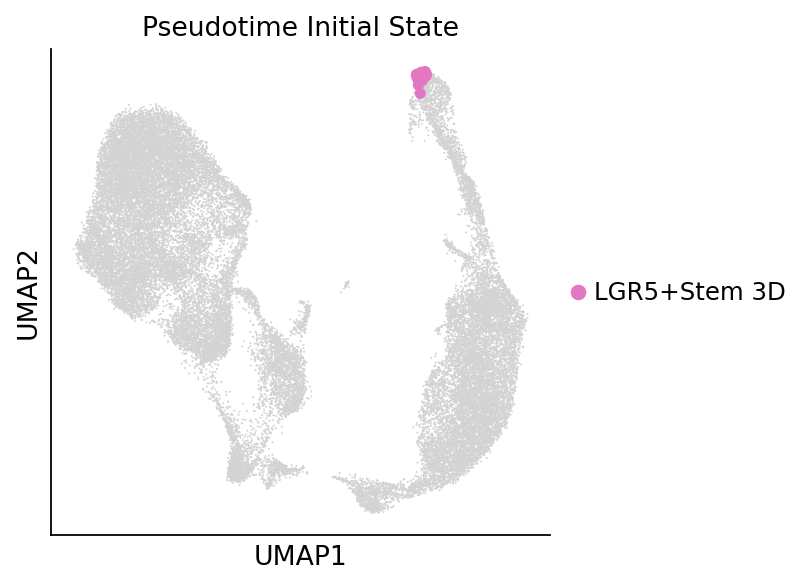

In [14]:
g2.set_initial_states(states=["LGR5+Stem_3D"])
g2.plot_macrostates(which="initial", s=100, legend_loc = "right", title = "Pseudotime Initial State", 
                    save="Supp_Fig3B_1.png"
                   )

In [15]:
g2.compute_fate_probabilities( tol = 1e-7)

Defaulting to `'gmres'` solver.


  0%|          | 0/3 [00:00<?, ?/s]

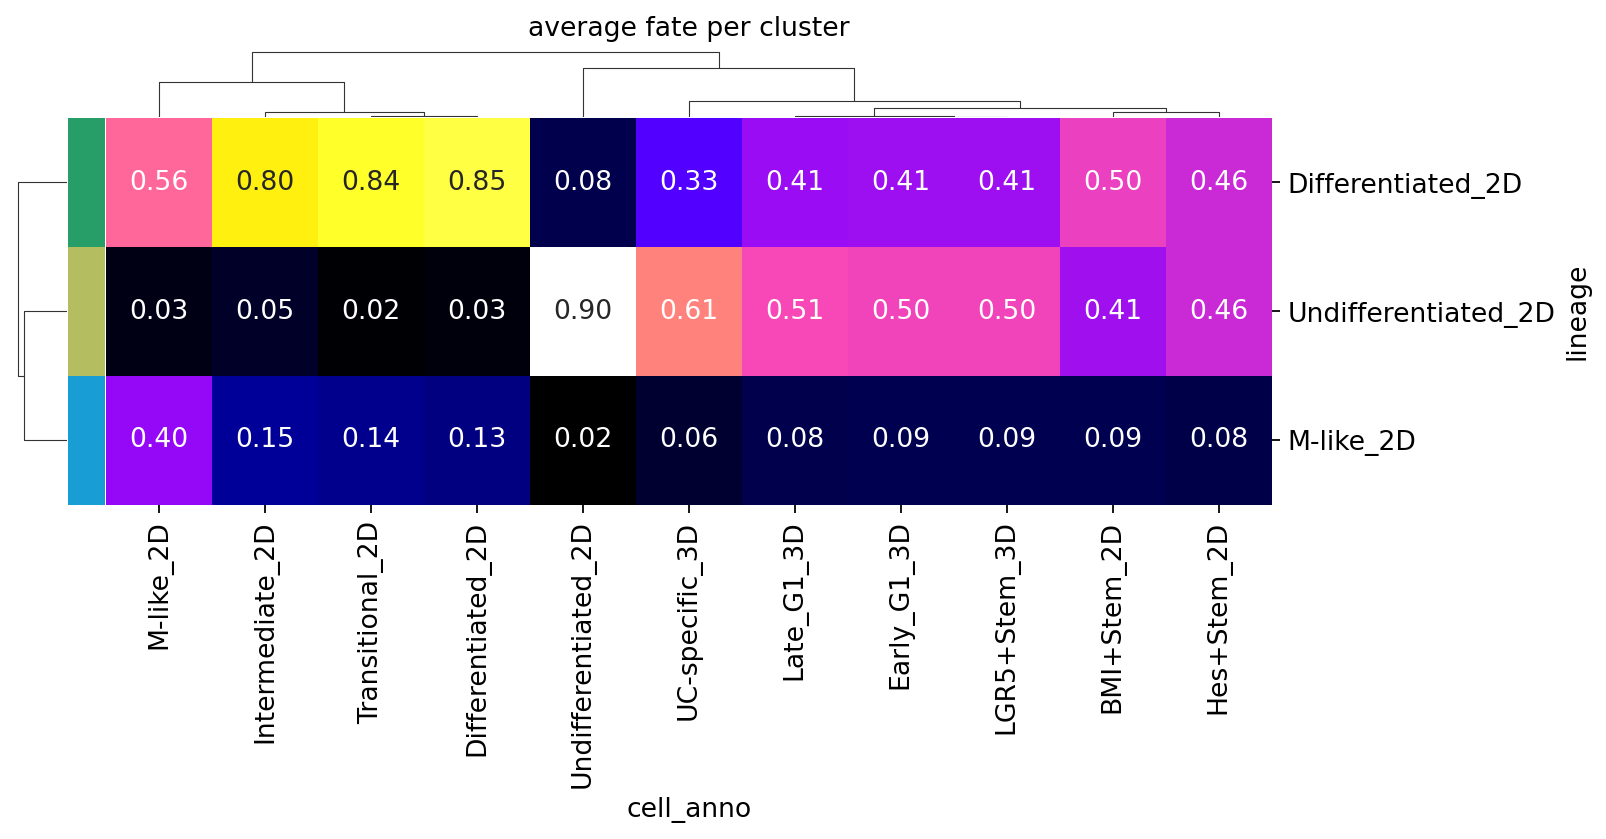

In [17]:
cr.pl.aggregate_fate_probabilities(adata,
                                   cluster_key = "cell_anno",
                                   mode = 'clustermap', 
                                   figsize = (10,5),
                                   cmap = "gnuplot2",
                                   cbar=False,
                                   save ="Supplementary_Figure3C.png" 
                                  )

  0%|          | 0/16 [00:00<?, ?gene/s]

did not converge
did not converge


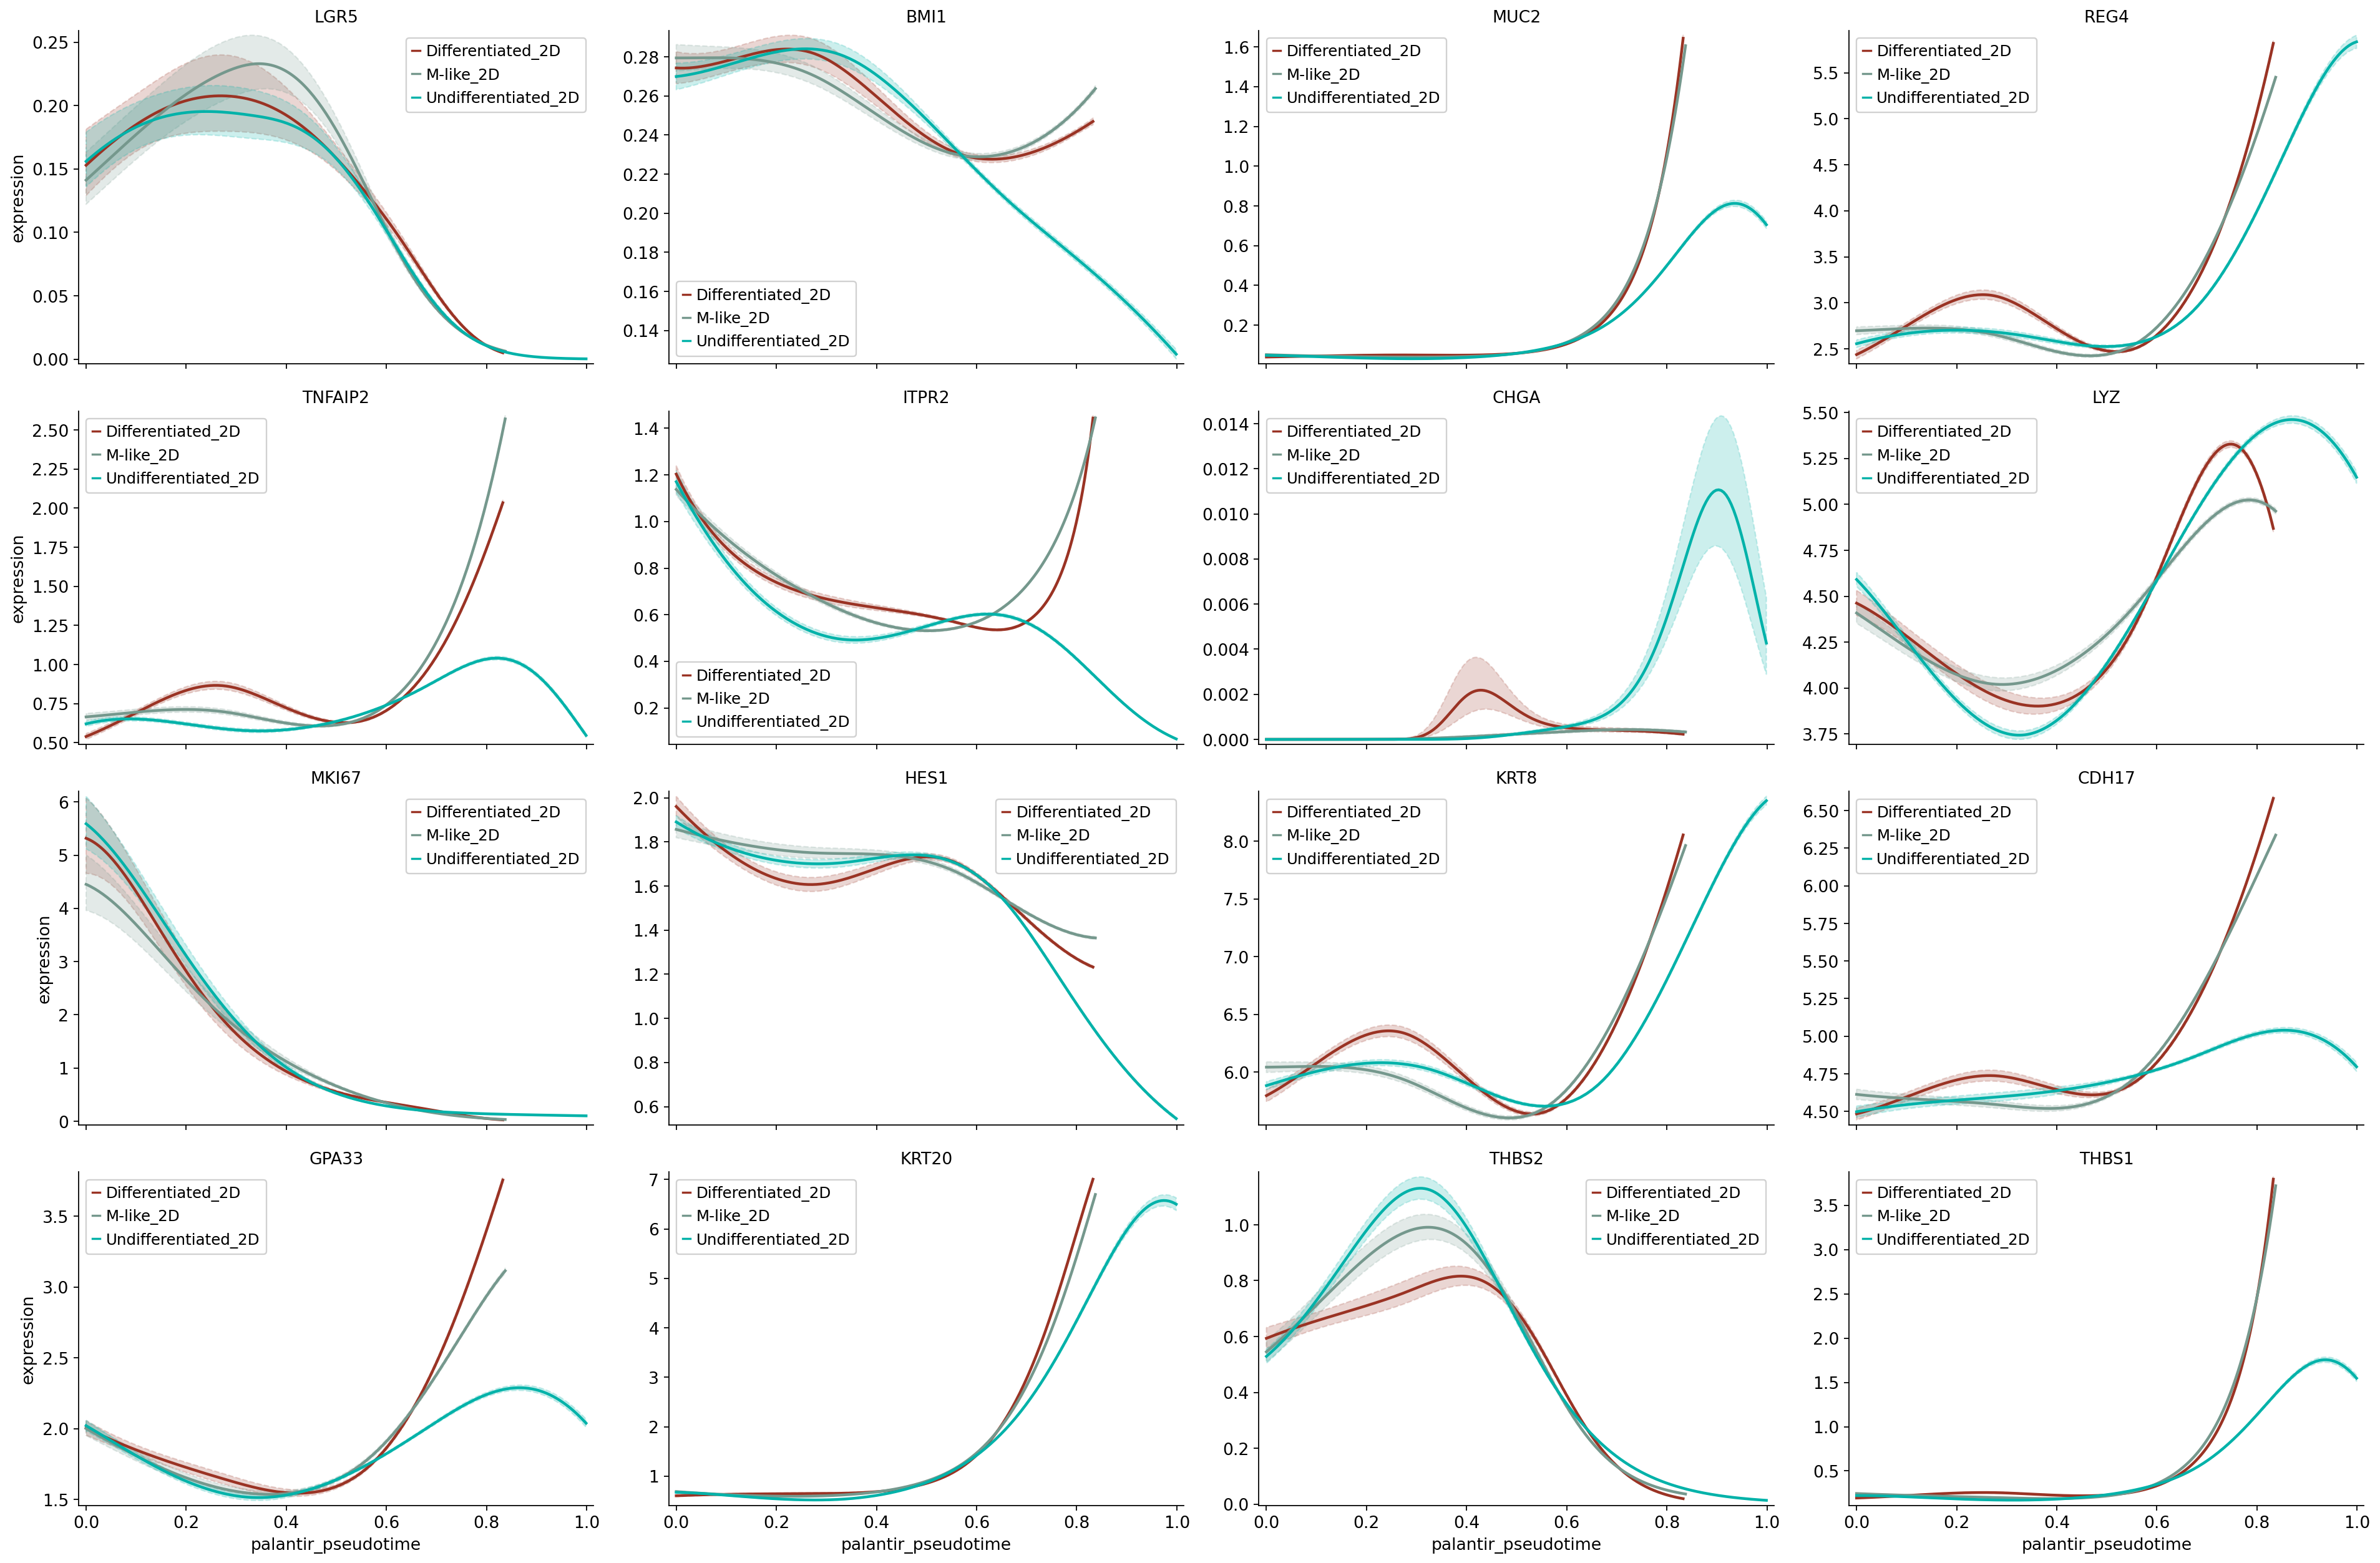

In [18]:
genes = ["LGR5","BMI1","MUC2","REG4",
         "TNFAIP2","ITPR2","CHGA","LYZ",
         "MKI67","HES1","KRT8","CDH17",
         "GPA33","KRT20","THBS2","THBS1"]
cr.pl.gene_trends(
    adata,
    model=model,
    data_key="MAGIC_imputed_data",
    genes = genes,
    lineage_cmap=["#9A3324","#75988d","#00B2A9"],
    same_plot=True,
    ncols=4,
    time_key="palantir_pseudotime",
    hide_cells=True,
    save = "Supplementary_Figure3D.png"
)